In [ ]:
#Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

In [ ]:
def CargaDatosLineal():
    #X: Features - caracteristicas.
    #y: Etiquetas - label.

    df = pd.read_excel('DatosClasificacion2DLinear.xlsx')
    X = df[ df.columns[0:2] ].values
    y = df['vehiculo'].values
    return X,y


def CargaDatosCirculo():
    #X: Features - caracteristicas.
    #y: Etiquetas - label.

    df = pd.read_excel('DatosClasificacion2DCirculo.xlsx')
    X = df[ df.columns[0:2] ].values
    y = df['vehiculo'].values
    return X,y


def CargaDatosEspiral():
    #X: Features - caracteristicas.
    #y: Etiquetas - label.

    df = pd.read_excel('DatosClasificacion2DEspiral.xlsx')
    X = df[ df.columns[0:2] ].values
    y = df['vehiculo'].values
    return X,y


def DibujaDatos(X,y,n):
    #X: Features - caracteristicas.
    #y: Etiquetas - label.
    #n: n° de puntos a dibujar

    X0 = X[y==0,:] #Caracteriticas con elementos de clase 0
    X1 = X[y==1,:] ##Caracteriticas con elementos de clase 1
    plt.figure()
    plt.plot(X0[:n,0],X0[:n,1],'x', mec='darkblue', label='No')
    plt.plot(X1[:n,0],X1[:n,1],'o', mec='darkred', mfc='none', label='Si')
    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.legend()


def OptimizaModelo(X,y,n,kernel,orden):
    #X: Caracteristicas
    #y: Label
    #n: N° de puntos a considerar para la optimización
    #kernel: kernel a utilizar en el clasificador
    #orden: orden del polinomio en caso de kernel polinomico
    #modelo: modelo obtenido por scikit learn

    X = X[:n,:]
    y = y[:n]
    modelo = svm.SVC(gamma='scale',kernel=kernel,degree=orden)
    modelo.fit(X, y)
    return modelo


def EvaluaModelo(X,y,modelo):
    #X: Caracteristica
    #y: Label
    #modelo: modelo obtenido por scikit learn
    #ACC: Accuracy (exactitud) del modelo

    ACC = modelo.score(X,y) #Accuracy
    return ACC


def DrawRegiones(modelo):
    #modelo: modelo obtenido por scikit learn

    x1lim = plt.xlim() #Limites del eje horizontal
    x2lim = plt.ylim() #Limites del eje vertical
    ngrid = 50 #Nº de puntos en cada dirección de la rejilla (grid) de dibujo
    x1 = np.linspace(x1lim[0], x1lim[1], ngrid) #Valores horizontales del grid
    x2 = np.linspace(x2lim[0], x2lim[1], ngrid) #Valores verticales del grid
    dx1 = ( x1[1] - x1[0] )/2 #Tamaño horizontal de cuadrí­cula del grid
    dx2 = ( x2[1] - x2[0] )/2 #Tamaño vertical de cuadrícula del grid
    TablaColor = ('lightblue','pink') #Colores de regiones clase 0 y 1
    for i in range(ngrid): #Itera en la dirección horizontal del grid
        for j in range(ngrid):  #Itera en la dirección vertical del grid
            xi = np.array([[x1[i], x2[j]]]) #Coordenadas del punto del grid
            yi = modelo.predict(xi) #Clase estimada del punto del grid
            x1p = [x1[i]-dx1, x1[i]+dx1, x1[i]+dx1, x1[i]-dx1 ]
            x2p = [x2[j]-dx2, x2[j]-dx2, x2[j]+dx2, x2[j]+dx2 ]
            color = TablaColor[int(yi)]
            plt.fill(x1p,x2p, color=color, edgecolor='none')
    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.xlim(x1lim)
    plt.ylim(x2lim)


def DrawRegionesSVM(X,y,n,kernel,orden):
    #X: Caracteristicas
    #y: Label
    #n: nº de puntos a considerar para la optimización
    #kernel: kernel a utilizar en el clasificador
    #orden: orden del polinomio en caso de kernel polinomico
    #modelo: modelo obtenido por scikit learn

    modelo = OptimizaModelo(X,y,n,kernel,orden) #Obtiene modelo óptimo
    DibujaDatos(X,y,n)  #Dibuja los datos
    DrawRegiones(modelo)  #Dibuja las regiones


def DibujaCurvaAprendizaje(X,y):
    #X: Matriz de diseÃ±o
    #y: vector de objetivos (target)

    npuntos = 100 #Nº de puntos de la curva de aprendizaje
    ntrain_vector = np.linspace(5,600,npuntos) #Nº clientes training (vector)
    ACCtest = np.zeros(npuntos) #Reserva de espacio para el coste de testing
    kernel_vector = ('linear','poly','rbf')
    orden_vector = (0,2,0)
    label_vector = ('linear','poly2','gauss')
    nkernel = len(kernel_vector)

    plt.figure()
    for ikernel in range(nkernel):
        kernel = kernel_vector[ikernel]
        print(kernel)
        orden = orden_vector[ikernel]
        label = label_vector[ikernel]
        for k in range(npuntos):
            #Itera para distintos valores de ntrain
            #Optimiza el modelo para el Training Dataset
            ntrain = ntrain_vector[k]
            ntrain = ntrain.astype('int') #Lo convierte en un número entero
            Xtrain = X[:ntrain,:] #Vector de caracteristicas (training)
            ytrain = y[:ntrain] #Vector de label (training)
            modelo = OptimizaModelo(Xtrain,ytrain,ntrain,kernel,orden)

            #Cálculo del coste para el Test Dataset
            Xtest = X[ntrain:,:] #Vector de caracteristicas (test)
            ytest = y[ntrain:] #Vector de label (test)
            ACCtest[k] = EvaluaModelo(Xtest,ytest,modelo) #Coste (test)

        #Dibujo de la curva de aprendizaje
        plt.plot(ntrain_vector,ACCtest, label=label)

    plt.xlabel('Número de clientes para entrenamiento')
    plt.ylabel('Accuracy')
    plt.legend()


linear
poly
rbf
linear
poly
rbf


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


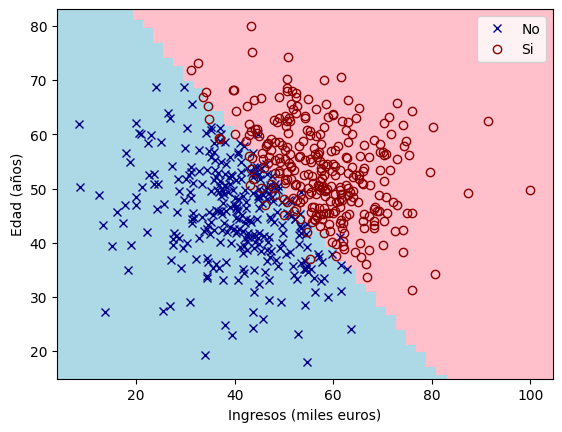

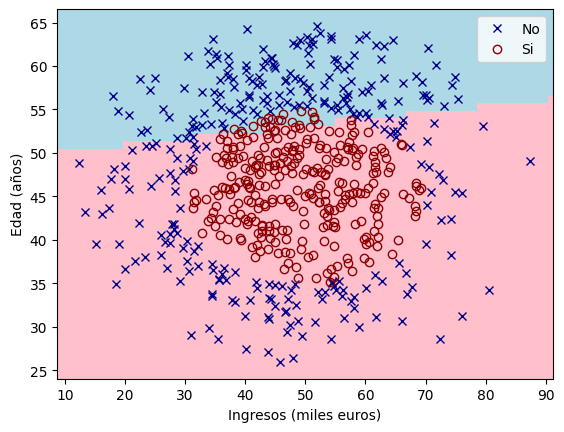

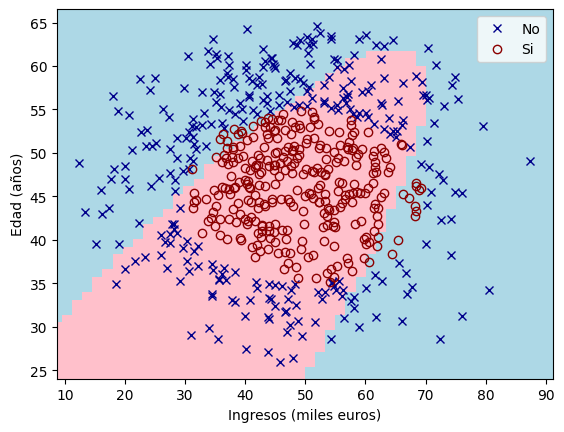

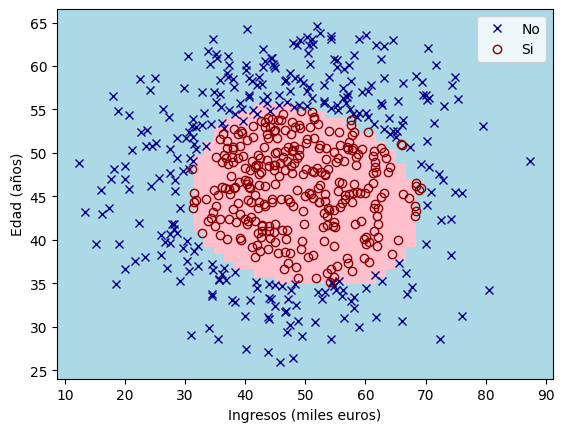

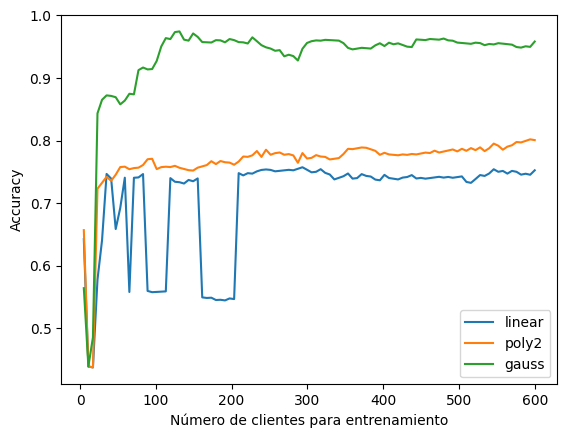

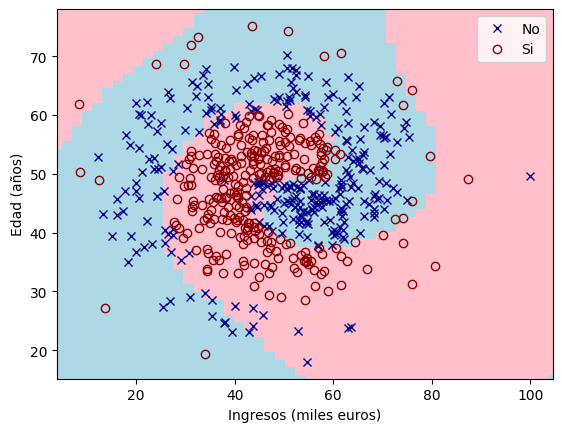

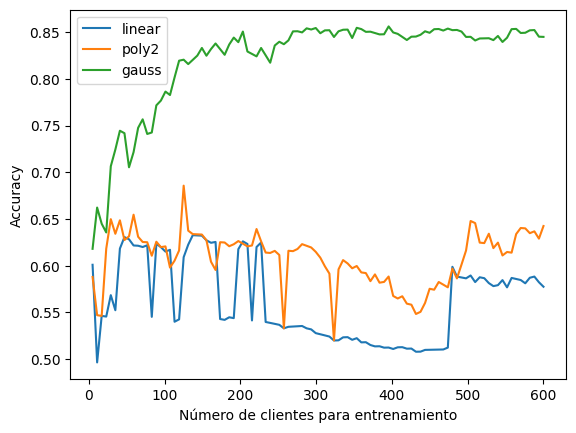

In [ ]:
X,y = CargaDatosLineal()
DrawRegionesSVM(X,y,300,'linear',0)

X,y = CargaDatosCirculo()
DrawRegionesSVM(X,y,300,'linear',0)

DrawRegionesSVM(X,y,300,'poly',2)

DrawRegionesSVM(X,y,300,'rbf',0)

DibujaCurvaAprendizaje(X,y)

X,y = CargaDatosEspiral()
DrawRegionesSVM(X,y,300,'rbf',0)
DibujaCurvaAprendizaje(X,y)

plt.show()

In [ ]:
df = pd.read_excel('DatosRegresion15D.xlsx')

IndexError: ignored

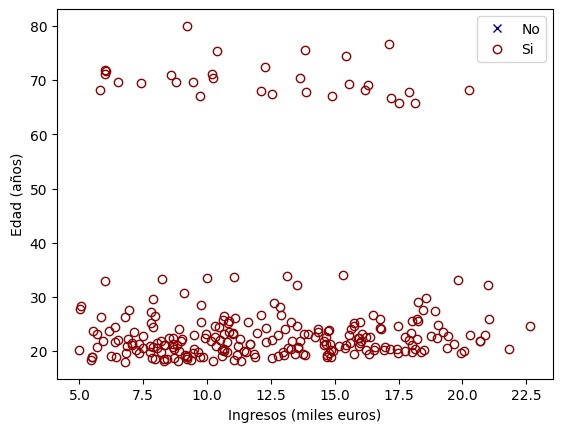

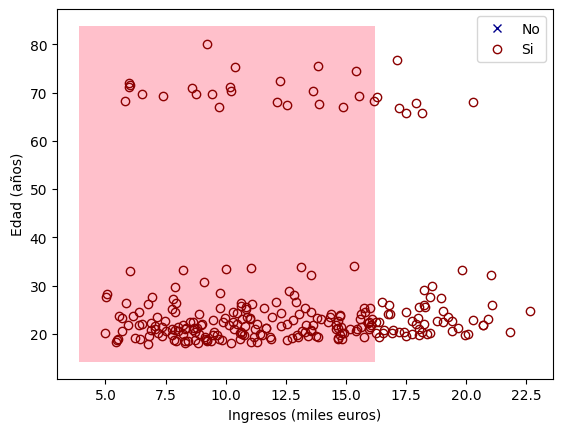

In [ ]:
import pandas as pd
from sklearn import svm
import numpy as np
import matplotlib.pyplot as plt

def ClasificarEstudio(df):
    # X: Características - 'ingresos' y 'edad'.
    # y: Etiquetas - clases de estudio.

    X = df[['ingresos', 'edad']].values
    y = df['estudios'].values

    # Define el modelo SVM. Puedes ajustar el kernel y otros parámetros según sea necesario.
    modelo = svm.SVC(gamma='scale', kernel='linear')

    # Ajusta el modelo a los datos.
    modelo.fit(X, y)

    return X, y, modelo

# Carga tus datos desde un archivo Excel.
df = pd.read_excel('DatosRegresion15D.xlsx')

# Clasifica los datos.
X, y, modelo = ClasificarEstudio(df)

# Dibuja los datos y las regiones de clasificación.
DibujaDatos(X, y, n=len(X))
DrawRegionesSVM(X, y, n=len(X), kernel='linear', orden=0)

# Dibuja la curva de aprendizaje si es necesario.
DibujaCurvaAprendizaje(X, y)

# Puedes evaluar el modelo utilizando EvaluaModelo si deseas.


In [ ]:
import pandas as pd
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def ClasificarEstudio(df):
    # X: Características - 'ingresos' y 'edad'.
    # y: Etiquetas - clases de estudio.

    X = df[['ingresos', 'edad']].values
    y = df['estudios'].values

    # Define el modelo SVM para clasificación multiclase.
    modelo = SVC(gamma='scale', kernel='linear')

    # Ajusta el modelo a los datos.
    modelo.fit(X, y)

    return X, y, modelo

# Carga tus datos desde un archivo Excel.
df = pd.read_excel('DatosRegresion15D.xlsx')

# Clasifica los datos.
X, y, modelo = ClasificarEstudio(df)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

def DibujaDatos(X, y, n):
    # X: Características.
    # y: Etiquetas.
    # n: Número de puntos a dibujar.

    plt.figure()
    for clase in np.unique(y):
        X_clase = X[y == clase]
        plt.scatter(X_clase[:n, 0], X_clase[:n, 1], label=f'Clase {clase}')

    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.legend()

def DrawRegionesSVM(X, y, n, kernel, orden):
    # X: Características.
    # y: Etiquetas.
    # n: Número de puntos a considerar para la optimización.
    # kernel: Kernel a utilizar en el clasificador.
    # orden: Orden del polinomio en caso de kernel polinómico.

    modelo = OptimizaModelo(X, y, n, kernel, orden)
    DibujaDatos(X, y, n)

    x1lim = plt.xlim()
    x2lim = plt.ylim()
    ngrid = 100
    x1 = np.linspace(x1lim[0], x1lim[1], ngrid)
    x2 = np.linspace(x2lim[0], x2lim[1], ngrid)
    dx1 = (x1[1] - x1[0]) / 2
    dx2 = (x2[1] - x2[0]) / 2
    TablaColor = ('lightblue', 'pink')

    for i in range(ngrid):
        for j in range(ngrid):
            xi = np.array([[x1[i], x2[j]]])
            yi = modelo.predict(xi)
            x1p = [x1[i] - dx1, x1[i] + dx1, x1[i] + dx1, x1[i] - dx1]
            x2p = [x2[j] - dx2, x2[j] - dx2, x2[j] + dx2, x2[j] + dx2]
            color = TablaColor[int(yi)]
            plt.fill(x1p, x2p, color=color, edgecolor='none')

    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.xlim(x1lim)
    plt.ylim(x2lim)


IndexError: ignored

/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


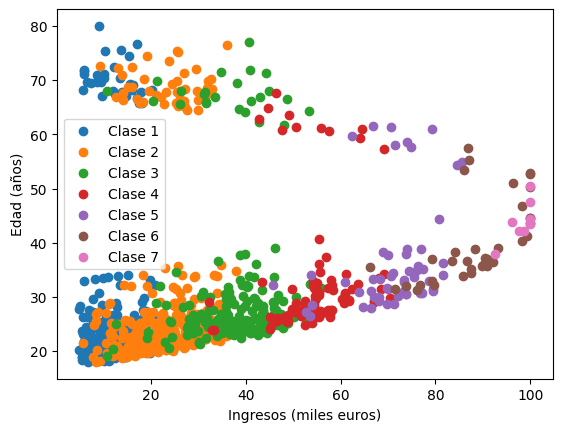

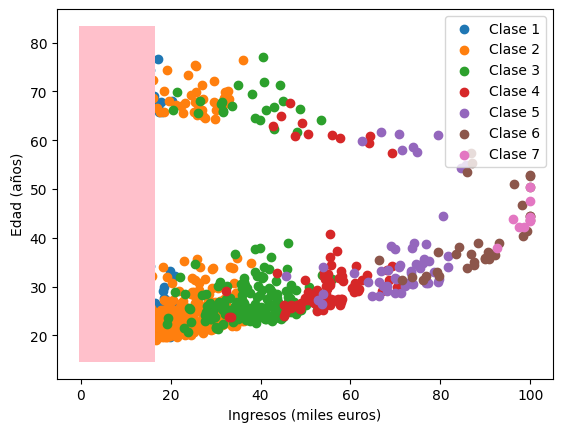

In [ ]:
# Dibuja los datos y las regiones de clasificación.
DibujaDatos(X, y, n=len(X))
DrawRegionesSVM(X, y, n=len(X), kernel='linear', orden=0)

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


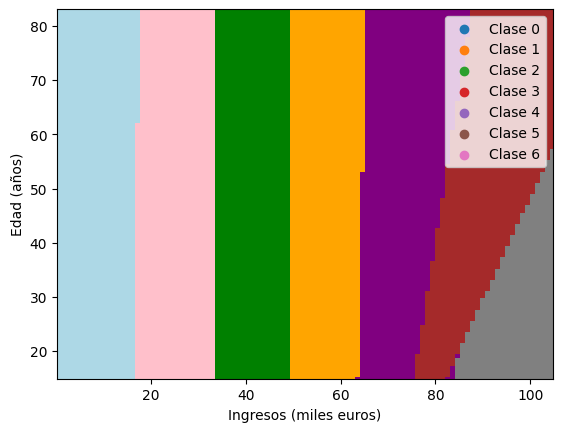

In [ ]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

def DibujaDatos(X, y):
    # X: Características.
    # y: Etiquetas.

    plt.figure()
    for clase in np.unique(y):
        X_clase = X[y == clase]
        plt.scatter(X_clase[:, 0], X_clase[:, 1], label=f'Clase {clase}')

    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.legend()

def DrawRegionesSVM(X, y, kernel, orden):
    # X: Características.
    # y: Etiquetas.
    # kernel: Kernel a utilizar en el clasificador.
    # orden: Orden del polinomio en caso de kernel polinómico.

    modelo = OptimizaModelo(X, y, kernel, orden)
    DibujaDatos(X, y)

    x1lim = plt.xlim()
    x2lim = plt.ylim()
    ngrid = 100
    x1 = np.linspace(x1lim[0], x1lim[1], ngrid)
    x2 = np.linspace(x2lim[0], x2lim[1], ngrid)
    dx1 = (x1[1] - x1[0]) / 2
    dx2 = (x2[1] - x2[0]) / 2
    TablaColor = ('lightblue', 'pink', 'green', 'orange', 'purple', 'brown', 'gray')

    for i in range(ngrid):
        for j in range(ngrid):
            xi = np.array([[x1[i], x2[j]]])
            yi = modelo.predict(xi)
            x1p = [x1[i] - dx1, x1[i] + dx1, x1[i] + dx1, x1[i] - dx1]
            x2p = [x2[j] - dx2, x2[j] - dx2, x2[j] + dx2, x2[j] + dx2]
            color = TablaColor[int(yi[0])]
            plt.fill(x1p, x2p, color=color, edgecolor='none')

    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.xlim(x1lim)
    plt.ylim(x2lim)

def OptimizaModelo(X, y, kernel, orden):
    # X: Características.
    # y: Etiquetas.
    # kernel: Kernel a utilizar en el clasificador.
    # orden: Orden del polinomio en caso de kernel polinómico.

    modelo = SVC(gamma='scale', kernel=kernel, degree=orden)
    modelo.fit(X, y)
    return modelo

# Carga tus datos desde el archivo Excel.
df = pd.read_excel('DatosRegresion15D.xlsx')

# Mapea las etiquetas a valores consecutivos a partir de 0
y = df['estudios'].values - 1

# Características para la clasificación
X = df[['ingresos', 'edad']].values

# Partición de los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Clasifica los datos con un kernel lineal y orden 0 (lineal)
kernel = 'linear'
orden = 0

# Dibuja los datos y las regiones de clasificación para el conjunto de entrenamiento
DrawRegionesSVM(X_train, y_train, kernel, orden)

# Muestra el gráfico
plt.show()


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


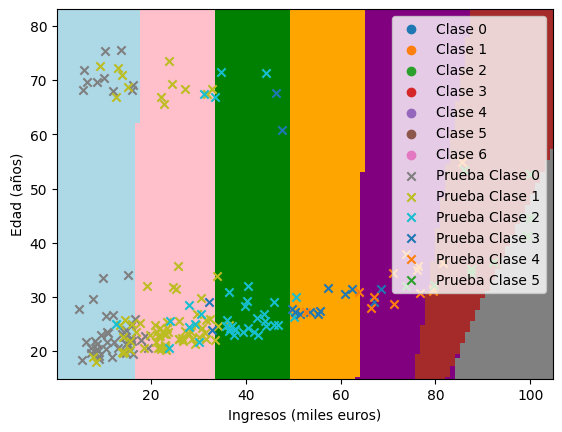

In [ ]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

def DibujaDatos(X, y):
    # X: Características.
    # y: Etiquetas.

    plt.figure()
    for clase in np.unique(y):
        X_clase = X[y == clase]
        plt.scatter(X_clase[:, 0], X_clase[:, 1], label=f'Clase {clase}')

    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.legend()

def DrawRegionesSVM(X, y, kernel, orden):
    # X: Características.
    # y: Etiquetas.
    # kernel: Kernel a utilizar en el clasificador.
    # orden: Orden del polinomio en caso de kernel polinómico.

    modelo = OptimizaModelo(X, y, kernel, orden)
    DibujaDatos(X, y)

    x1lim = plt.xlim()
    x2lim = plt.ylim()
    ngrid = 100
    x1 = np.linspace(x1lim[0], x1lim[1], ngrid)
    x2 = np.linspace(x2lim[0], x2lim[1], ngrid)
    dx1 = (x1[1] - x1[0]) / 2
    dx2 = (x2[1] - x2[0]) / 2
    TablaColor = ('lightblue', 'pink', 'green', 'orange', 'purple', 'brown', 'gray')

    for i in range(ngrid):
        for j in range(ngrid):
            xi = np.array([[x1[i], x2[j]]])
            yi = modelo.predict(xi)
            x1p = [x1[i] - dx1, x1[i] + dx1, x1[i] + dx1, x1[i] - dx1]
            x2p = [x2[j] - dx2, x2[j] - dx2, x2[j] + dx2, x2[j] + dx2]
            color = TablaColor[int(yi[0])]
            plt.fill(x1p, x2p, color=color, edgecolor='none')

    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.xlim(x1lim)
    plt.ylim(x2lim)

def OptimizaModelo(X, y, kernel, orden):
    # X: Características.
    # y: Etiquetas.
    # kernel: Kernel a utilizar en el clasificador.
    # orden: Orden del polinomio en caso de kernel polinómico.

    modelo = SVC(gamma='scale', kernel=kernel, degree=orden)
    modelo.fit(X, y)
    return modelo

# Carga tus datos desde el archivo Excel.
df = pd.read_excel('DatosRegresion15D.xlsx')

# Mapea las etiquetas a valores consecutivos a partir de 0
y = df['estudios'].values - 1

# Características para la clasificación
X = df[['ingresos', 'edad']].values

# Partición de los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Clasifica los datos con un kernel lineal y orden 0 (lineal)
kernel = 'linear'
orden = 0

# Dibuja los datos y las regiones de clasificación para el conjunto de entrenamiento
DrawRegionesSVM(X_train, y_train, kernel, orden)

# Dibuja los puntos de prueba en el mismo gráfico
for clase in np.unique(y_test):
    X_clase = X_test[y_test == clase]
    plt.scatter(X_clase[:, 0], X_clase[:, 1], label=f'Prueba Clase {clase}', marker='x')

# Muestra el gráfico
plt.legend()
plt.show()


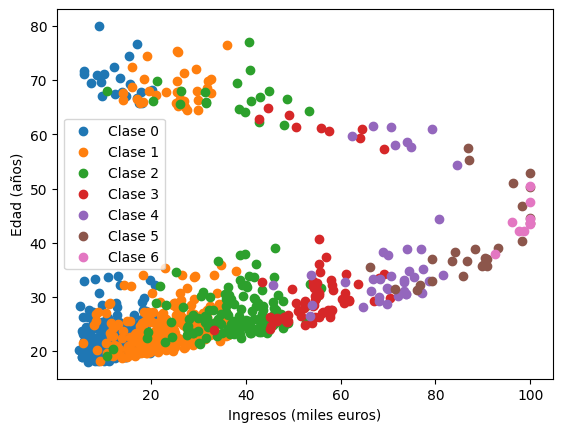

In [ ]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

def DibujaDatos(X, y):
    # X: Características.
    # y: Etiquetas.

    plt.figure()
    for clase in np.unique(y):
        X_clase = X[y == clase]
        plt.scatter(X_clase[:, 0], X_clase[:, 1], label=f'Clase {clase}')

    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.legend()

def OptimizaModelo(X, y, kernel, orden):
    # X: Características.
    # y: Etiquetas.
    # kernel: Kernel a utilizar en el clasificador.
    # orden: Orden del polinomio en caso de kernel polinómico.

    modelo = SVC(gamma='scale', kernel=kernel, degree=orden)
    modelo.fit(X, y)
    return modelo

# Carga tus datos desde el archivo Excel.
df = pd.read_excel('DatosRegresion15D.xlsx')

# Mapea las etiquetas a valores consecutivos a partir de 0
y = df['estudios'].values - 1

# Características para la clasificación
X = df[['ingresos', 'edad']].values

# Partición de los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Clasifica los datos con un kernel lineal y orden 0 (lineal)
kernel = 'linear'
orden = 0

# Dibuja los puntos de entrenamiento en el mismo gráfico
DibujaDatos(X_train, y_train)

# Muestra el gráfico
plt.show()


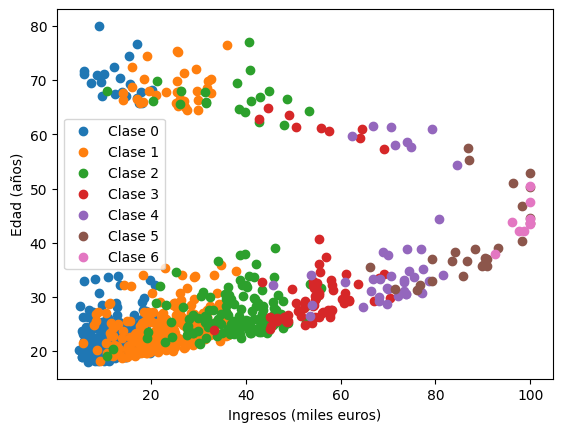

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


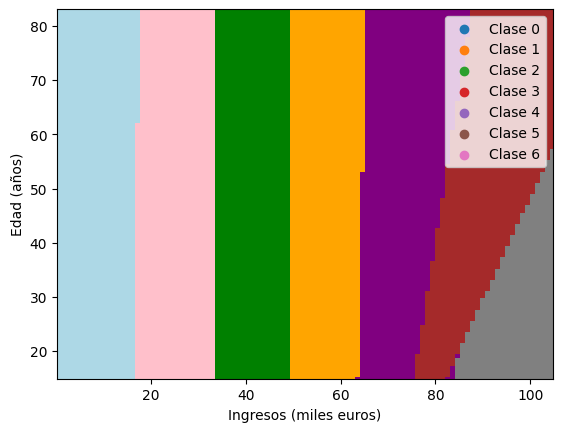

In [ ]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

def DibujaDatos(X, y):
    # X: Características.
    # y: Etiquetas.

    plt.figure()
    for clase in np.unique(y):
        X_clase = X[y == clase]
        plt.scatter(X_clase[:, 0], X_clase[:, 1], label=f'Clase {clase}')

    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.legend()

def DrawRegionesSVM(X, y, kernel, orden):
    # X: Características.
    # y: Etiquetas.
    # kernel: Kernel a utilizar en el clasificador.
    # orden: Orden del polinomio en caso de kernel polinómico.

    modelo = OptimizaModelo(X, y, kernel, orden)
    DibujaDatos(X, y)

    x1lim = plt.xlim()
    x2lim = plt.ylim()
    ngrid = 100
    x1 = np.linspace(x1lim[0], x1lim[1], ngrid)
    x2 = np.linspace(x2lim[0], x2lim[1], ngrid)
    dx1 = (x1[1] - x1[0]) / 2
    dx2 = (x2[1] - x2[0]) / 2
    TablaColor = ('lightblue', 'pink', 'green', 'orange', 'purple', 'brown', 'gray')

    for i in range(ngrid):
        for j in range(ngrid):
            xi = np.array([[x1[i], x2[j]]])
            yi = modelo.predict(xi)
            x1p = [x1[i] - dx1, x1[i] + dx1, x1[i] + dx1, x1[i] - dx1]
            x2p = [x2[j] - dx2, x2[j] - dx2, x2[j] + dx2, x2[j] + dx2]
            color = TablaColor[int(yi[0])]
            plt.fill(x1p, x2p, color=color, edgecolor='none')

    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.xlim(x1lim)
    plt.ylim(x2lim)

def OptimizaModelo(X, y, kernel, orden):
    # X: Características.
    # y: Etiquetas.
    # kernel: Kernel a utilizar en el clasificador.
    # orden: Orden del polinomio en caso de kernel polinómico.

    modelo = SVC(gamma='scale', kernel=kernel, degree=orden)
    modelo.fit(X, y)
    return modelo

# Carga tus datos desde el archivo Excel.
df = pd.read_excel('DatosRegresion15D.xlsx')

# Mapea las etiquetas a valores consecutivos a partir de 0
y = df['estudios'].values - 1

# Características para la clasificación
X = df[['ingresos', 'edad']].values

# Partición de los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Clasifica los datos con un kernel lineal y orden 0 (lineal)
kernel = 'linear'
orden = 0

# Dibuja los puntos de entrenamiento y las regiones de clasificación en el mismo gráfico
DibujaDatos(X_train, y_train)
DrawRegionesSVM(X_train, y_train, kernel, orden)

# Muestra el gráfico
plt.show()


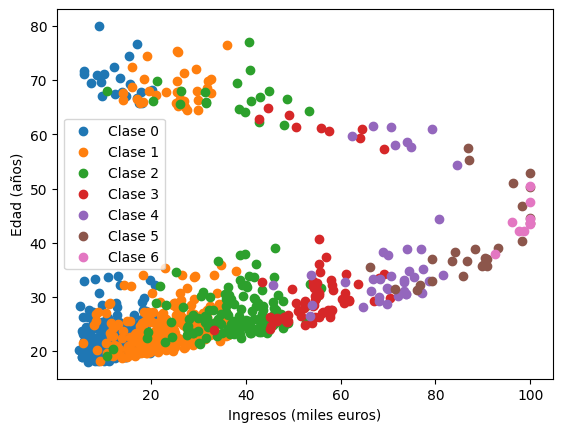

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


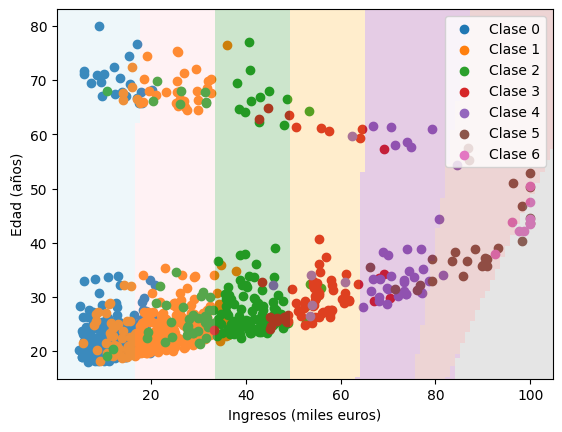

In [ ]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

def DibujaDatos(X, y):
    # X: Características.
    # y: Etiquetas.

    plt.figure()
    for clase in np.unique(y):
        X_clase = X[y == clase]
        plt.scatter(X_clase[:, 0], X_clase[:, 1], label=f'Clase {clase}')

    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.legend()

def DrawRegionesSVM(X, y, kernel, orden):
    # X: Características.
    # y: Etiquetas.
    # kernel: Kernel a utilizar en el clasificador.
    # orden: Orden del polinomio en caso de kernel polinómico.

    modelo = OptimizaModelo(X, y, kernel, orden)
    DibujaDatos(X, y)

    x1lim = plt.xlim()
    x2lim = plt.ylim()
    ngrid = 100
    x1 = np.linspace(x1lim[0], x1lim[1], ngrid)
    x2 = np.linspace(x2lim[0], x2lim[1], ngrid)
    dx1 = (x1[1] - x1[0]) / 2
    dx2 = (x2[1] - x2[0]) / 2
    TablaColor = ('lightblue', 'pink', 'green', 'orange', 'purple', 'brown', 'gray')

    for i in range(ngrid):
        for j in range(ngrid):
            xi = np.array([[x1[i], x2[j]]])
            yi = modelo.predict(xi)
            x1p = [x1[i] - dx1, x1[i] + dx1, x1[i] + dx1, x1[i] - dx1]
            x2p = [x2[j] - dx2, x2[j] - dx2, x2[j] + dx2, x2[j] + dx2]
            color = TablaColor[int(yi[0])]
            plt.fill(x1p, x2p, color=color, alpha=0.2, edgecolor='none')  # Ajusta la transparencia aquí

    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.xlim(x1lim)
    plt.ylim(x2lim)

def OptimizaModelo(X, y, kernel, orden):
    # X: Características.
    # y: Etiquetas.
    # kernel: Kernel a utilizar en el clasificador.
    # orden: Orden del polinomio en caso de kernel polinómico.

    modelo = SVC(gamma='scale', kernel=kernel, degree=orden)
    modelo.fit(X, y)
    return modelo

# Carga tus datos desde el archivo Excel.
df = pd.read_excel('DatosRegresion15D.xlsx')

# Mapea las etiquetas a valores consecutivos a partir de 0
y = df['estudios'].values - 1

# Características para la clasificación
X = df[['ingresos', 'edad']].values

# Partición de los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Clasifica los datos con un kernel lineal y orden 0 (lineal)
kernel = 'linear'
orden = 0

# Dibuja los puntos de entrenamiento y las regiones de clasificación en el mismo gráfico
DibujaDatos(X_train, y_train)
DrawRegionesSVM(X_train, y_train, kernel, orden)

# Muestra el gráfico
plt.show()


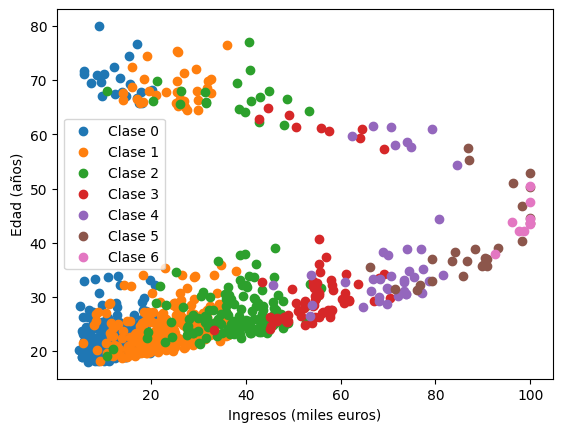

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


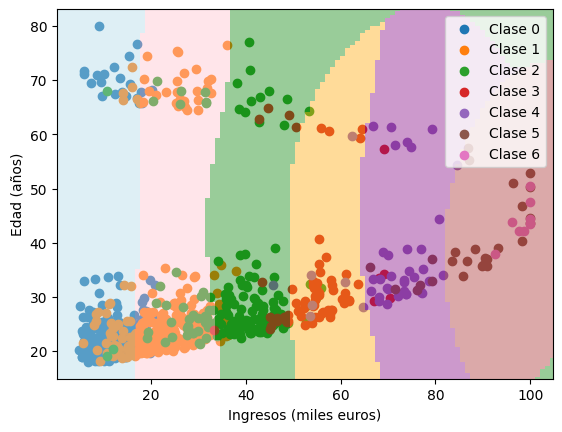

In [ ]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

def DibujaDatos(X, y):
    # X: Características.
    # y: Etiquetas.

    plt.figure()
    for clase in np.unique(y):
        X_clase = X[y == clase]
        plt.scatter(X_clase[:, 0], X_clase[:, 1], label=f'Clase {clase}')

    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.legend()

def DrawRegionesSVM(X, y, kernel, orden):
    # X: Características.
    # y: Etiquetas.
    # kernel: Kernel a utilizar en el clasificador.
    # orden: Orden del polinomio en caso de kernel polinómico.

    modelo = OptimizaModelo(X, y, kernel, orden)
    DibujaDatos(X, y)

    x1lim = plt.xlim()
    x2lim = plt.ylim()
    ngrid = 100
    x1 = np.linspace(x1lim[0], x1lim[1], ngrid)
    x2 = np.linspace(x2lim[0], x2lim[1], ngrid)
    dx1 = (x1[1] - x1[0]) / 2
    dx2 = (x2[1] - x2[0]) / 2
    TablaColor = ('lightblue', 'pink', 'green', 'orange', 'purple', 'brown', 'gray')

    for i in range(ngrid):
        for j in range(ngrid):
            xi = np.array([[x1[i], x2[j]]])
            yi = modelo.predict(xi)
            x1p = [x1[i] - dx1, x1[i] + dx1, x1[i] + dx1, x1[i] - dx1]
            x2p = [x2[j] - dx2, x2[j] - dx2, x2[j] + dx2, x2[j] + dx2]
            color = TablaColor[int(yi[0])]
            plt.fill(x1p, x2p, color=color, alpha=0.4, edgecolor='none')  # Ajusta la transparencia aquí

    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.xlim(x1lim)
    plt.ylim(x2lim)

def OptimizaModelo(X, y, kernel, orden):
    # X: Características.
    # y: Etiquetas.
    # kernel: Kernel a utilizar en el clasificador.
    # orden: Orden del polinomio en caso de kernel polinómico.

    modelo = SVC(gamma='scale', kernel=kernel, degree=orden)
    modelo.fit(X, y)
    return modelo

# Carga tus datos desde el archivo Excel.
df = pd.read_excel('DatosRegresion15D.xlsx')

# Mapea las etiquetas a valores consecutivos a partir de 0
y = df['estudios'].values - 1

# Características para la clasificación
X = df[['ingresos', 'edad']].values

# Partición de los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Clasifica los datos con un kernel gaussiano (RBF)
kernel = 'rbf'
orden = 0

# Dibuja los puntos de entrenamiento y las regiones de clasificación en el mismo gráfico
DibujaDatos(X_train, y_train)
DrawRegionesSVM(X_train, y_train, kernel, orden)

# Muestra el gráfico
plt.show()


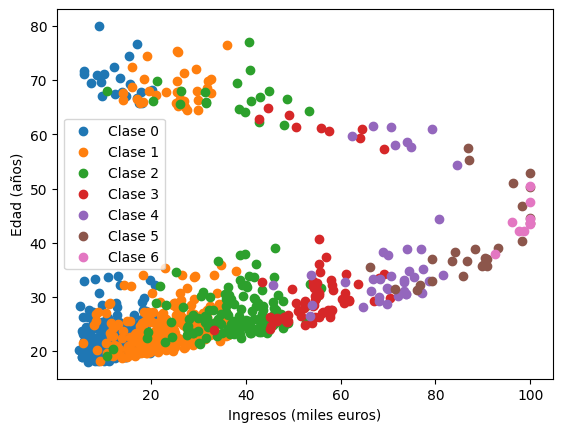

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


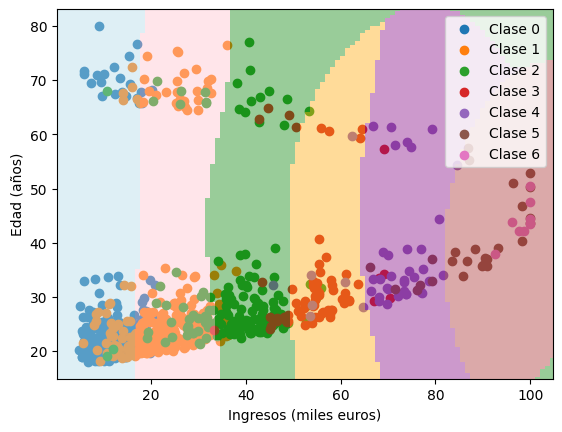

In [ ]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

def DibujaDatos(X, y):
    # X: Características.
    # y: Etiquetas.

    plt.figure()
    for clase in np.unique(y):
        X_clase = X[y == clase]
        plt.scatter(X_clase[:, 0], X_clase[:, 1], label=f'Clase {clase}')

    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.legend()

def DrawRegionesSVM(X, y, kernel):
    # X: Características.
    # y: Etiquetas.
    # kernel: Kernel a utilizar en el clasificador.

    modelo = OptimizaModelo(X, y, kernel)
    DibujaDatos(X, y)

    x1lim = plt.xlim()
    x2lim = plt.ylim()
    ngrid = 100
    x1 = np.linspace(x1lim[0], x1lim[1], ngrid)
    x2 = np.linspace(x2lim[0], x2lim[1], ngrid)
    dx1 = (x1[1] - x1[0]) / 2
    dx2 = (x2[1] - x2[0]) / 2
    TablaColor = ('lightblue', 'pink', 'green', 'orange', 'purple', 'brown', 'gray')

    for i in range(ngrid):
        for j in range(ngrid):
            xi = np.array([[x1[i], x2[j]]])
            yi = modelo.predict(xi)
            x1p = [x1[i] - dx1, x1[i] + dx1, x1[i] + dx1, x1[i] - dx1]
            x2p = [x2[j] - dx2, x2[j] - dx2, x2[j] + dx2, x2[j] + dx2]
            color = TablaColor[int(yi[0])]
            plt.fill(x1p, x2p, color=color, alpha=0.4, edgecolor='none')  # Ajusta la transparencia aquí

    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.xlim(x1lim)
    plt.ylim(x2lim)

def OptimizaModelo(X, y, kernel):
    # X: Características.
    # y: Etiquetas.
    # kernel: Kernel a utilizar en el clasificador.

    modelo = SVC(gamma='scale', kernel=kernel)
    modelo.fit(X, y)
    return modelo

# Carga tus datos desde el archivo Excel.
df = pd.read_excel('DatosRegresion15D.xlsx')

# Mapea las etiquetas a valores consecutivos a partir de 0
y = df['estudios'].values - 1

# Características para la clasificación
X = df[['ingresos', 'edad']].values

# Partición de los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Clasifica los datos con un kernel radial (RBF)
kernel = 'rbf'

# Dibuja los puntos de entrenamiento y las regiones de clasificación en el mismo gráfico
DibujaDatos(X_train, y_train)
DrawRegionesSVM(X_train, y_train, kernel)

# Muestra el gráfico
plt.show()


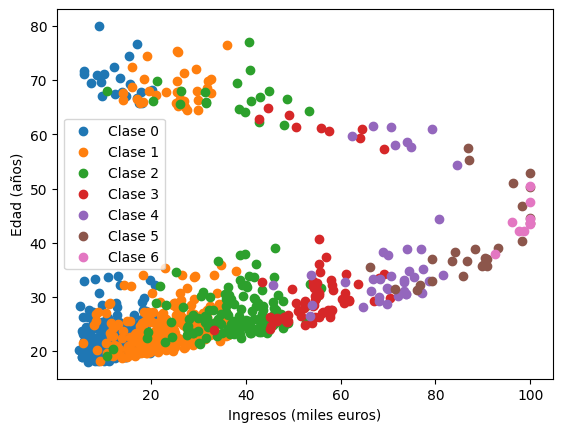

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


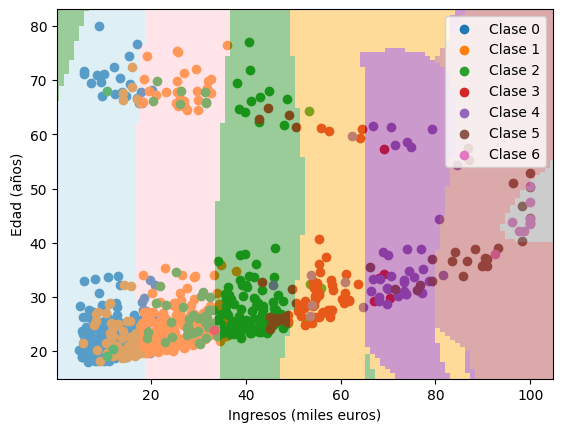

In [ ]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

def DibujaDatos(X, y):
    # X: Características.
    # y: Etiquetas.

    plt.figure()
    for clase in np.unique(y):
        X_clase = X[y == clase]
        plt.scatter(X_clase[:, 0], X_clase[:, 1], label=f'Clase {clase}')

    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.legend()

def DrawRegionesSVM(X, y, kernel):
    # X: Características.
    # y: Etiquetas.
    # kernel: Kernel a utilizar en el clasificador.

    modelo = OptimizaModelo(X, y, kernel)
    DibujaDatos(X, y)

    x1lim = plt.xlim()
    x2lim = plt.ylim()
    ngrid = 100
    x1 = np.linspace(x1lim[0], x1lim[1], ngrid)
    x2 = np.linspace(x2lim[0], x2lim[1], ngrid)
    dx1 = (x1[1] - x1[0]) / 2
    dx2 = (x2[1] - x2[0]) / 2
    TablaColor = ('lightblue', 'pink', 'green', 'orange', 'purple', 'brown', 'gray')

    for i in range(ngrid):
        for j in range(ngrid):
            xi = np.array([[x1[i], x2[j]]])
            yi = modelo.predict(xi)
            x1p = [x1[i] - dx1, x1[i] + dx1, x1[i] + dx1, x1[i] - dx1]
            x2p = [x2[j] - dx2, x2[j] - dx2, x2[j] + dx2, x2[j] + dx2]
            color = TablaColor[int(yi[0])]
            plt.fill(x1p, x2p, color=color, alpha=0.4, edgecolor='none')  # Ajusta la transparencia aquí

    plt.xlabel('Ingresos (miles euros)')
    plt.ylabel('Edad (años)')
    plt.xlim(x1lim)
    plt.ylim(x2lim)

def OptimizaModelo(X, y, kernel):
    # X: Características.
    # y: Etiquetas.
    # kernel: Kernel a utilizar en el clasificador.

    modelo = SVC(gamma='scale', kernel=kernel, degree=4)  # Grado 4 para el kernel polinómico
    modelo.fit(X, y)
    return modelo

# Carga tus datos desde el archivo Excel.
df = pd.read_excel('DatosRegresion15D.xlsx')

# Mapea las etiquetas a valores consecutivos a partir de 0
y = df['estudios'].values - 1

# Características para la clasificación
X = df[['ingresos', 'edad']].values

# Partición de los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Clasifica los datos con un kernel polinómico de grado 4
kernel = 'poly'

# Dibuja los puntos de entrenamiento y las regiones de clasificación en el mismo gráfico
DibujaDatos(X_train, y_train)
DrawRegionesSVM(X_train, y_train, kernel)

# Muestra el gráfico
plt.show()
